In [20]:
# =====================================================================
# SEL 1: IMPORT LIBRARY & SETUP
# =====================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
import optuna

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Import Algoritma Juara (Telah Disesuaikan)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor

# Mengurangi log yang terlalu berisik di terminal
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("--- [SEL 1] Library berhasil dimuat secara optimal. ---")

--- [SEL 1] Library berhasil dimuat secara optimal. ---


In [21]:
# =====================================================================
# SEL 2: LOAD & PERSIAPKAN DATA
# =====================================================================
# Pastikan path ini benar sesuai struktur direktori LENTERA LAUT
data_path = os.path.join("..", "data", "processed", "modeling_ready.csv")

try:
    df = pd.read_csv(data_path)
    print(f"--- [SEL 2] Data berhasil dimuat: {len(df)} baris. ---")
except FileNotFoundError:
    print(f"ERROR: Berkas tidak ditemukan di {data_path}. Periksa kembali direktori.")

# Ekstraksi kolom lag sebagai fitur prediktor independen
feature_cols = [col for col in df.columns if "_lag" in col]
X_raw = df[feature_cols]

# Imputasi untuk sterilisasi nilai NaN yang tersisa
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

print(f"✅ Fitur siap digunakan: {X.shape[1]} kolom prediktor.")

--- [SEL 2] Data berhasil dimuat: 4125 baris. ---
✅ Fitur siap digunakan: 18 kolom prediktor.


In [22]:
# =====================================================================
# SEL 3: DEFINISI RUANG PENCARIAN (TUNING SETUP)
# =====================================================================
# Pemetaan 1 model terbaik (Peringkat 1) berdasarkan R-Squared PyCaret
best_baseline_models = {
    "ocean_current_velocity": "ExtraTreesRegressor",
    "precipitation": "LGBMRegressor",         # Berubah menjadi LGBM
    "sea_surface_temperature": "ExtraTreesRegressor", # Berubah menjadi ExtraTrees
    "visibility": "ExtraTreesRegressor",
    "wave_height": "LinearRegression",
    "wind_speed_10m": "RandomForestRegressor" # Berubah menjadi Random Forest
}

# Inisialisasi MLflow Tracking Server
mlflow.set_tracking_uri("file:./mlruns")

print("--- [SEL 3] Konfigurasi arsitektur model terbaik berhasil ditetapkan. ---")

--- [SEL 3] Konfigurasi arsitektur model terbaik berhasil ditetapkan. ---


In [23]:
# =====================================================================
# SEL 4: PROSES OPTUNA TUNING & MLFLOW LOGGING
# =====================================================================
summary_tuned = []
all_best_params = {} # Direktori penyimpanan parameter mutakhir

print("--- [SEL 4] MEMULAI OPTIMASI OPTUNA UNTUK TOP 1 MODEL ---")

for target_var, best_algo in best_baseline_models.items():
    print(f"\n{'='*20} TARGET: {target_var} {'='*20}")
    
    y = df[target_var]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    mlflow.set_experiment(f"LenteraLaut_v4_Tuned_{target_var}")
    
    if best_algo == "LinearRegression":
        print(f" -> [INFO] {best_algo} dilewati karena merupakan model parametrik kaku.")
        all_best_params[target_var] = {}
        
        # Log baseline langsung untuk LinReg agar tetap masuk ke tabel summary
        model_lr = LinearRegression()
        model_lr.fit(X_train, y_train)
        preds_lr = model_lr.predict(X_test)
        r2_lr = r2_score(y_test, preds_lr)
        rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
        summary_tuned.append({"Target": target_var, "Model": best_algo, "R2": r2_lr, "RMSE": rmse_lr})
        continue
        
    print(f" -> Optuna sedang mengeksekusi iterasi hyperparameter untuk {best_algo}...")

    def objective(trial):
        if best_algo == "ExtraTreesRegressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 200),
                "max_depth": trial.suggest_categorical("max_depth", [5, 10, 15, None]),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "random_state": 123, "n_jobs": 1
            }
            temp_model = ExtraTreesRegressor(**params)
            
        elif best_algo == "RandomForestRegressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 200),
                "max_depth": trial.suggest_categorical("max_depth", [5, 10, 15, None]),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "random_state": 123, "n_jobs": 1
            }
            temp_model = RandomForestRegressor(**params)
            
        elif best_algo == "LGBMRegressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 200),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth": trial.suggest_int("max_depth", 3, 12),
                "random_state": 123, "n_jobs": 1, "verbose": -1
            }
            temp_model = LGBMRegressor(**params)

        temp_model.fit(X_train, y_train)
        return r2_score(y_test, temp_model.predict(X_test))

    # Eksekusi Tuning via Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10) # Set n_trials lebih tinggi (misal 30) untuk optimasi maksimal
    
    best_params = study.best_params
    all_best_params[target_var] = best_params
    
    # Rekonstruksi model final dengan parameter terkalibrasi
    if best_algo == "ExtraTreesRegressor":
        final_model = ExtraTreesRegressor(**best_params, random_state=123, n_jobs=1)
    elif best_algo == "RandomForestRegressor":
        final_model = RandomForestRegressor(**best_params, random_state=123, n_jobs=1)
    elif best_algo == "LGBMRegressor":
        best_params.update({"random_state": 123, "n_jobs": 1, "verbose": -1})
        final_model = LGBMRegressor(**best_params)

    # MLflow Tracking Phase
    with mlflow.start_run(run_name=f"Optuna_{best_algo}"):
        final_model.fit(X_train, y_train)
        preds = final_model.predict(X_test)
        
        r2 = r2_score(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        
        mlflow.log_params(best_params)
        mlflow.log_metrics({"R2": r2, "RMSE": rmse})
        mlflow.sklearn.log_model(final_model, "tuned_model")
        
        summary_tuned.append({"Target": target_var, "Model": best_algo, "R2": r2, "RMSE": rmse})
        print(f"    ✅ [Selesai] R2 Teroptimasi untuk {target_var}: {r2:.4f}")

--- [SEL 4] MEMULAI OPTIMASI OPTUNA UNTUK TOP 1 MODEL ---

==================== TARGET: ocean_current_velocity ====================
 -> Optuna sedang mengeksekusi iterasi hyperparameter untuk ExtraTreesRegressor...


2026/05/21 21:26:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:26:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ✅ [Selesai] R2 Teroptimasi untuk ocean_current_velocity: 0.9816

==================== TARGET: precipitation ====================
 -> Optuna sedang mengeksekusi iterasi hyperparameter untuk LGBMRegressor...


2026/05/21 21:27:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:27:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ✅ [Selesai] R2 Teroptimasi untuk precipitation: 0.5426

==================== TARGET: sea_surface_temperature ====================
 -> Optuna sedang mengeksekusi iterasi hyperparameter untuk ExtraTreesRegressor...


...

    ✅ [Selesai] R2 Teroptimasi untuk sea_surface_temperature: 0.9980

==================== TARGET: visibility ====================
 -> Optuna sedang mengeksekusi iterasi hyperparameter untuk ExtraTreesRegressor...


2026/05/21 21:27:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:27:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ✅ [Selesai] R2 Teroptimasi untuk visibility: 0.6875

==================== TARGET: wave_height ====================
 -> [INFO] LinearRegression dilewati karena merupakan model parametrik kaku.

==================== TARGET: wind_speed_10m ====================
 -> Optuna sedang mengeksekusi iterasi hyperparameter untuk RandomForestRegressor...


2026/05/21 21:27:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:27:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ✅ [Selesai] R2 Teroptimasi untuk wind_speed_10m: 0.8320


In [24]:
# =====================================================================
# SEL 5: TABEL RINGKASAN PERFORMA SETELAH TUNING OPTUNA
# =====================================================================
print("\n--- TABEL RINGKASAN PERFORMA SETELAH TUNING OPTUNA ---")

df_tuned_summary = pd.DataFrame(summary_tuned)

if not df_tuned_summary.empty:
    df_tuned_summary = df_tuned_summary.sort_values(by="R2", ascending=False).reset_index(drop=True)
    
    styled_tuned_summary = df_tuned_summary.style.background_gradient(
        subset=["R2"], cmap="YlGn"
    ).background_gradient(
        subset=["RMSE"], cmap="Reds"
    ).format({
        "R2": "{:.4f}",
        "RMSE": "{:.4f}"
    })
    
    display(styled_tuned_summary)
else:
    print("[INFO] Tabel kosong. Pastikan proses tuning di Sel 4 sudah dieksekusi sempurna.")


--- TABEL RINGKASAN PERFORMA SETELAH TUNING OPTUNA ---


,Target,Model,R2,RMSE
0,wave_height,LinearRegression,0.9997,0.0098
1,sea_surface_temperature,ExtraTreesRegressor,0.9980,0.0524
2,ocean_current_velocity,ExtraTreesRegressor,0.9816,0.1453
3,wind_speed_10m,RandomForestRegressor,0.8320,1.6319
4,visibility,ExtraTreesRegressor,0.6875,3183.9900
5,precipitation,LGBMRegressor,0.5426,0.2805


--- [SEL 6] GENERASI KURVA PEMBELAJARAN (LEARNING CURVES) ---

Memproses Kurva Pembelajaran untuk Target: ocean_current_velocity (ExtraTreesRegressor)...


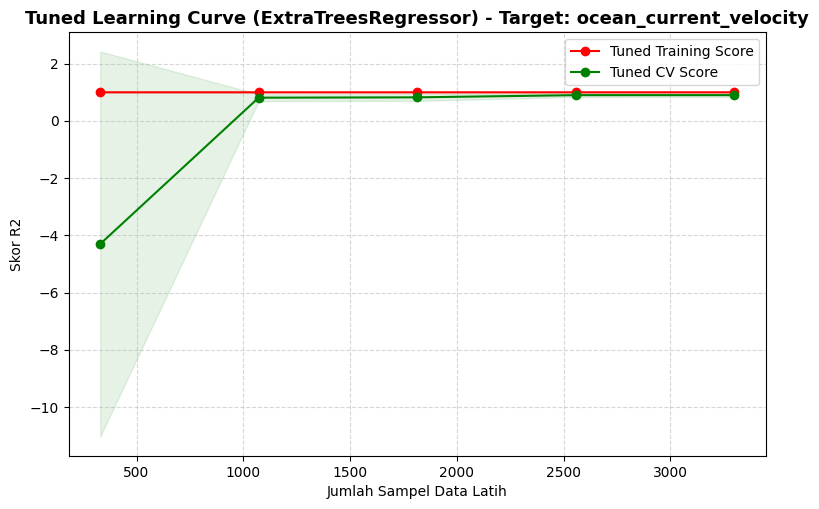

    ✅ [SUKSES] Grafik tersimpan: learning_curve_ocean_current_velocity_tuned.png

Memproses Kurva Pembelajaran untuk Target: precipitation (LGBMRegressor)...


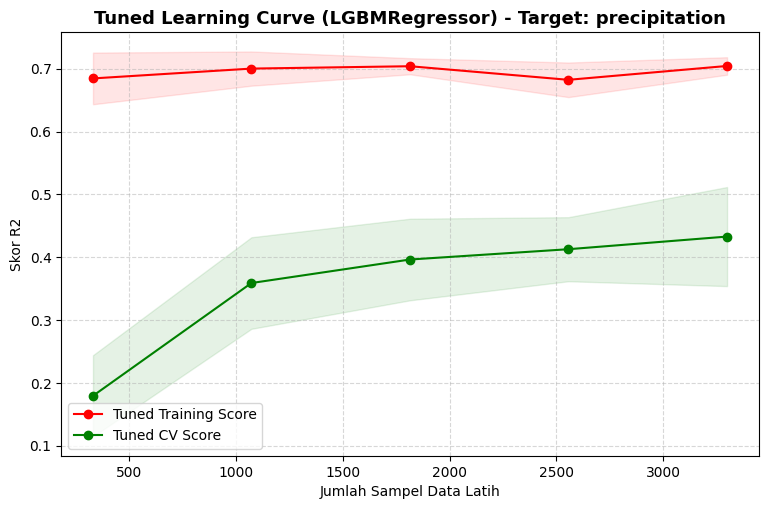

    ✅ [SUKSES] Grafik tersimpan: learning_curve_precipitation_tuned.png

Memproses Kurva Pembelajaran untuk Target: sea_surface_temperature (ExtraTreesRegressor)...


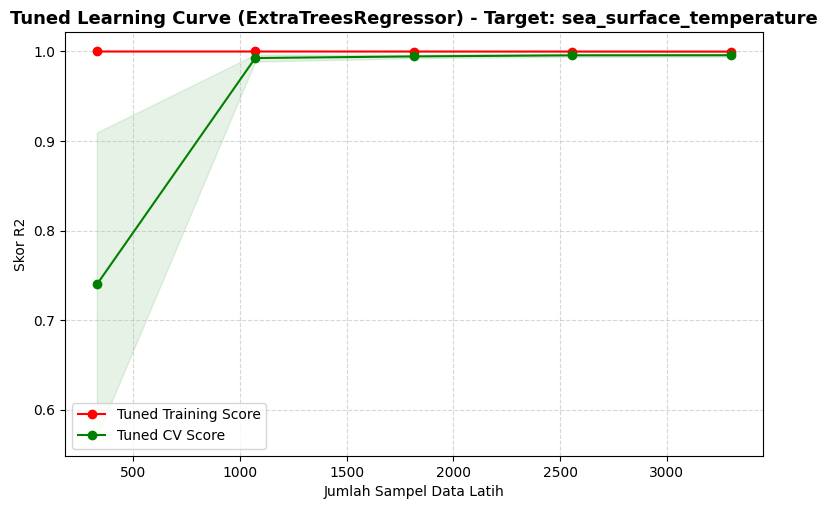

    ✅ [SUKSES] Grafik tersimpan: learning_curve_sea_surface_temperature_tuned.png

Memproses Kurva Pembelajaran untuk Target: visibility (ExtraTreesRegressor)...


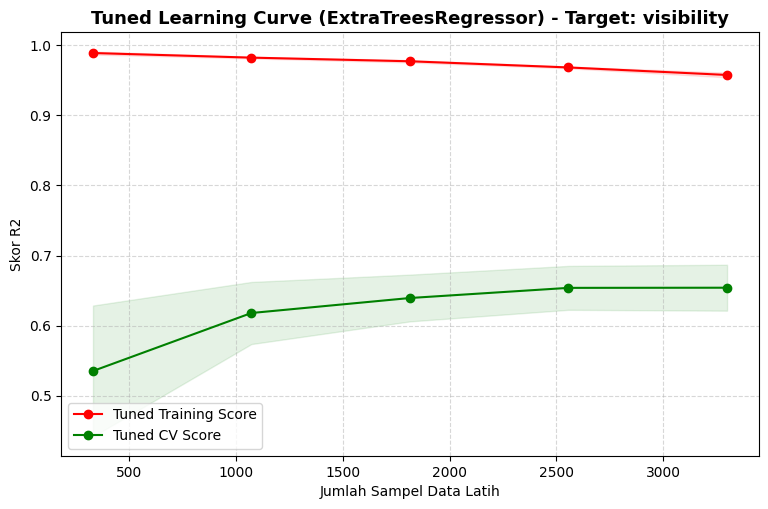

    ✅ [SUKSES] Grafik tersimpan: learning_curve_visibility_tuned.png

Memproses Kurva Pembelajaran untuk Target: wind_speed_10m (RandomForestRegressor)...


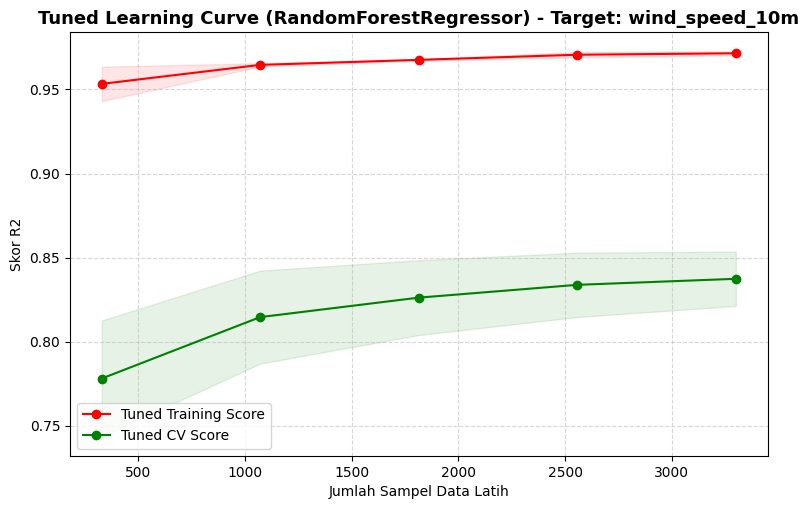

    ✅ [SUKSES] Grafik tersimpan: learning_curve_wind_speed_10m_tuned.png

--- PROSES PENYUSUNAN SELURUH KURVA SELESAI ---


In [25]:
# =====================================================================
# SEL 6: MENYUSUN KURVA PEMBELAJARAN UNTUK MODEL HASIL TUNING
# =====================================================================
print("--- [SEL 6] GENERASI KURVA PEMBELAJARAN (LEARNING CURVES) ---")

for target_var, best_algo in best_baseline_models.items():
    if best_algo == "LinearRegression":
        continue
        
    print(f"\nMemproses Kurva Pembelajaran untuk Target: {target_var} ({best_algo})...")
    y_eval = df[target_var]
    
    try:
        optimal_params = all_best_params.get(target_var, {})
        
        if best_algo == "ExtraTreesRegressor":
            model_tuned = ExtraTreesRegressor(**optimal_params, random_state=123, n_jobs=1)
        elif best_algo == "RandomForestRegressor":
            model_tuned = RandomForestRegressor(**optimal_params, random_state=123, n_jobs=1)
        elif best_algo == "LGBMRegressor":
            optimal_params.update({"random_state": 123, "n_jobs": 1, "verbose": -1})
            model_tuned = LGBMRegressor(**optimal_params)
            
        pipeline_tuned = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')), 
            ('model', model_tuned)
        ])
        
        train_sizes, train_scores, test_scores = learning_curve(
            estimator=pipeline_tuned,
            X=X,
            y=y_eval,
            train_sizes=np.linspace(0.1, 1.0, 5),
            cv=5,
            scoring='r2',
            n_jobs=1,
            random_state=123
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        
        plt.figure(figsize=(9, 5.5))
        
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Tuned Training Score")
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Tuned CV Score")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
        
        plt.title(f"Tuned Learning Curve ({best_algo}) - Target: {target_var}", fontsize=13, fontweight='bold')
        plt.xlabel("Jumlah Sampel Data Latih")
        plt.ylabel("Skor R2")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="best")
        
        filename = f"learning_curve_{target_var}_tuned.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"    ✅ [SUKSES] Grafik tersimpan: {filename}")
        
    except Exception as e:
        print(f"    ❌ [GAGAL] Terjadi kesalahan saat memproses {target_var}: {e}")

print("\n--- PROSES PENYUSUNAN SELURUH KURVA SELESAI ---")